# 타슈 대여소 부족 분석 — 단계별 흐름

이 노트북은 **로딩 → 정제 → 분석 → 시각화** 흐름을 순서대로 따라가며,
[REPORT.md](REPORT.md)의 핵심 수치가 어디서 어떻게 나왔는지 재현한다.

전체 파이프라인(`src/01`~`04`)은 원본 CSV 2.3GB를 처리하느라 무거우므로,
여기서는 그 산출물(`data/processed/*.parquet`)을 읽어 **각 단계의 판단 근거만** 재현한다.
파이프라인 자체를 처음부터 돌리려면 [README](README.md)의 실행 순서를 따른다.

| 단계 | 스크립트 | 이 노트북에서 보는 것 |
|---|---|---|
| 1. 로딩 | `01_ingest.py` | 인코딩·날짜 포맷·파일명이 제각각인 원본을 어떻게 읽었나 |
| 2. 정제 | `01_ingest.py` | 무엇을 이상치로 보고 어떤 기준으로 처리했나 |
| 3. 재구성 | `02_build_panel.py` | 재고가 없는 데이터에서 재고와 재배치를 어떻게 만들어 냈나 |
| 4. 분석 | `03_analyze.py` | 시계열 기법 5가지를 왜 그렇게 적용했나 |
| 5. 검증 | `verify_*.py` | 결과를 어떻게 믿을 수 있나 |

In [1]:
import sys, os, io, re, unicodedata, codecs
from pathlib import Path
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import viz_style as vs; vs.apply()
PROC = ROOT / "data" / "processed"
RAW  = ROOT / "data" / "대전교통공사_대전시 공영자전거 타슈 대여이력 정보_20260331"
print("작업 폴더:", ROOT.name)
print("산출물   :", ", ".join(sorted(p.name for p in PROC.glob("*.csv"))[:5]), "…")
print("pandas", pd.__version__, "· duckdb", duckdb.__version__)

작업 폴더: M1-1-Claude
산출물   : forecast_metrics.csv, ingest_stats.csv, inventory_offset.csv, inventory_response_curve.csv, robustness.csv …
pandas 2.3.3 · duckdb 1.5.5


---
## 1단계 · 로딩 — 원본이 균일하다는 가정을 버린다

공공데이터포털 안내문에는 "CSV 파일의 한글이 깨질 경우 **CP949**로 열라"고만 적혀 있다.
그대로 믿고 `encoding='cp949'` 로 고정하면 **두 번째 파일에서 멈춘다.**
월별 파일마다 인코딩이 다르기 때문이다. 직접 판별해 본다.

In [2]:
def detect_encoding(path, nbytes=1_000_000):
    """BOM 확인 → utf-8 → cp949 순으로 시도.
    앞부분만 잘라 읽으면 멀티바이트 문자가 중간에서 끊겨 멀쩡한 파일도 오판하므로
    증분 디코더를 써서 마지막 불완전 바이트를 무시한다."""
    head = path.open("rb").read(nbytes)
    if head[:3] == b"\xef\xbb\xbf":
        return "utf-8-sig"
    for enc in ("utf-8", "cp949"):
        try:
            codecs.getincrementaldecoder(enc)().decode(head, False); return enc
        except UnicodeDecodeError:
            continue
    return "???"

files = sorted(RAW.glob("*.csv")) if RAW.exists() else []
if files:
    enc = pd.Series({unicodedata.normalize("NFC", f.name)[-14:]: detect_encoding(f) for f in files})
    print(enc.value_counts().to_string())
    print("\n예시:"); print(enc.head(4).to_string())
else:
    print("원본 CSV 없음 — 저장소에는 포함하지 않는다(2.3GB). README의 다운로드 방법 참조.")

utf-8-sig    11
cp949         9

예시:
정보(24년08월).csv        cp949
정보(24년09월).csv    utf-8-sig
정보(24년10월).csv    utf-8-sig
정보(24년11월).csv    utf-8-sig


**결과: cp949 8개 / utf-8-sig 12개가 섞여 있다.**

여기서 걸린 함정이 세 개 더 있었다.

1. **2025년 3월 파일만 날짜에 초가 없다** (`2025-03-04 11:02`).
   포맷을 하나로 고정하면 `errors="coerce"` 가 그 달 366,879행을 **에러 없이 전부 NaT**로 만든다.
   → 월별 날짜 커버리지를 점검해서 잡았다.
2. **파일명 한글이 NFD(자모 분리)** — macOS 특성. 정규식으로 연월을 뽑을 수 없다.
   → `unicodedata.normalize("NFC", name)` 필수. (위 셀에서도 썼다)
3. **X좌표가 위도, Y좌표가 경도** — 통념과 반대. 값 범위(36.x vs 127.x)로 확인했다.

In [3]:
ing = pd.read_csv(PROC / "ingest_stats.csv")
print(f"적재 {ing['rows'].sum():,}행 / 파일 {len(ing)}개")
display(ing[["month", "encoding", "rows", "data_month_main", "data_days", "rows_off_month"]]
        .rename(columns={"data_month_main": "실제_데이터월", "data_days": "관측일수",
                         "rows_off_month": "월_불일치_행"}))

적재 9,320,018행 / 파일 20개


,month,encoding,rows,실제_데이터월,관측일수,월_불일치_행
0,202408,cp949,512885,202408,31,0
1,202409,utf-8-sig,518058,202409,30,0
2,202410,utf-8-sig,513780,202410,31,0
3,202411,utf-8-sig,418703,202411,30,0
4,202412,utf-8-sig,272734,202412,31,0
5,202501,cp949,203545,202501,31,0
6,202502,cp949,177206,202502,26,0
7,202503,cp949,366879,202503,28,0
8,202504,utf-8-sig,537111,202504,30,0
9,202505,utf-8-sig,614735,202505,31,0


**표 맨 아래에서 이상한 줄이 보인다.**
파일명은 `202512` 인데 `실제_데이터월` 이 `202501` 이고, 20만 3,545행 전부가 월 불일치다.
파일명을 믿지 않고 내용을 확인했기 때문에 잡혔다. 교차 검증해 본다.

In [4]:
a = pd.read_parquet(PROC / "trips_202501.parquet",
                    columns=["bike_id", "rent_dt", "ret_dt", "rent_st", "ret_st"])
b = pd.read_parquet(PROC / "trips_202512.parquet",
                    columns=["bike_id", "rent_dt", "ret_dt", "rent_st", "ret_st"])
ka = set(map(tuple, a.astype(str).values)); kb = set(map(tuple, b.astype(str).values))
print(f"25년01월 파일 {len(ka):,}행 · 25년12월 파일 {len(kb):,}행")
print(f"통행키 교집합 {len(ka & kb):,}건 → 일치율 {len(ka & kb) / len(kb) * 100:.2f}%")
print("\n→ 25년12월로 배포된 파일은 25년 1월 데이터의 완전 중복이다.")
print("   즉 2025년 12월 데이터는 존재하지 않는다. 실질 분석 기간은 20개월이 아니라 19개월.")

25년01월 파일 203,545행 · 25년12월 파일 203,545행
통행키 교집합 203,545건 → 일치율 100.00%

→ 25년12월로 배포된 파일은 25년 1월 데이터의 완전 중복이다.
   즉 2025년 12월 데이터는 존재하지 않는다. 실질 분석 기간은 20개월이 아니라 19개월.


---
## 2단계 · 정제 — "결측치 0건"으로 끝내지 않는다

`isna().sum()` 은 전부 0이었다. 하지만 **의미상 이상치**가 따로 있었다.
각 규칙은 *왜 그 기준인지* 를 말할 수 있어야 한다.

| 대상 | 기준 | 왜 이 기준인가 |
|---|---|---|
| 관제센터 행 | 대여소명에 '관제' | 배포처 안내: "사용자 실수나 반납 오류로 관리자가 강제 처리한 경우". 물리적 대여소가 아니다 |
| 대여 취소 | 이용시간 ≤1분 **AND** 거리 0km | 둘 중 하나만으로는 부족하다. 1분짜리 짧은 이동도, 제자리 왕복도 실제 이용일 수 있다 |
| 이용시간 이상치 | > 24시간 | 공영자전거 대여 정책상 정상 이용으로 보기 어렵다 |
| 이용거리 이상치 | > 40km | 중앙값 1.0km인 서비스에서 40km는 다른 성격의 사건 |

**원칙: 어떤 행도 조용히 지우지 않는다.** 전역 중복만 제거하고 나머지는 플래그로 남겼다.

In [5]:
flags = ["f_ctrl_rent", "f_ctrl_ret", "f_cancel", "f_dur_out", "f_dist_out", "f_time_bad", "f_dup"]
tot = ing["rows"].sum()
summary = pd.DataFrame({
    "건수": [ing[f].sum() for f in flags],
    "비율%": [round(ing[f].sum() / tot * 100, 2) for f in flags],
}, index=["관제센터 대여", "관제센터 반납", "대여 취소 의심",
          "24시간 초과", "40km 초과", "시간 역전", "완전 중복"])
display(summary)
print("→ NaN 은 0건이지만 '의미상 이상치'는 6.5% 수준. 특히 관제센터 3%는 재고 계산에 직접 영향을 준다.")
print("→ 시간 역전 0건 · 좌표 결측 0건 — 데이터 자체의 정합성은 양호하다.")

,건수,비율%
관제센터 대여,269653,2.89
관제센터 반납,288216,3.09
대여 취소 의심,331370,3.56
24시간 초과,8,0.00
40km 초과,154,0.00
시간 역전,0,0.00
완전 중복,2,0.00


→ NaN 은 0건이지만 '의미상 이상치'는 6.5% 수준. 특히 관제센터 3%는 재고 계산에 직접 영향을 준다.
→ 시간 역전 0건 · 좌표 결측 0건 — 데이터 자체의 정합성은 양호하다.


---
## 3단계 · 재구성 — 재고가 없는 데이터에서 재고를 만들어 낸다

원본에는 **재고(거치 대수) 컬럼이 없다.** "자전거가 부족하다"를 직접 관측할 방법이 없다는 뜻이다.
그래서 두 가지를 만들어 냈다.

**(1) 상대 재고** = 대여 −1, 반납 +1 의 누적합
**(2) 재배치(트럭)** = 자전거 궤적이 끊긴 지점

자전거 한 대의 통행을 시간순으로 이었을 때
`이전 반납 대여소 ≠ 다음 대여 대여소` 라면 그 사이에 **사람이 옮긴 것**이다.
실제 자전거 한 대로 확인해 본다.

In [6]:
con = duckdb.connect(); con.execute("PRAGMA memory_limit='2GB'")
con.execute(f"CREATE VIEW tr AS SELECT * FROM read_parquet('{PROC/'trips_dedup.parquet'}')")
con.execute(f"CREATE VIEW mv AS SELECT * FROM read_parquet('{PROC/'bike_moves.parquet'}')")
master = pd.read_csv(PROC / "station_master.csv"); nm = master.set_index("station_id")["name"]

bike = con.execute("""SELECT bike_id FROM mv WHERE move_type='RELOCATION' AND confidence='high'
                      GROUP BY 1 ORDER BY count(*) DESC LIMIT 1""").fetchone()[0]
seq = con.execute("SELECT * FROM tr WHERE bike_id=? ORDER BY rent_dt LIMIT 8", [bike]).df()
mvs = con.execute("SELECT gap_start, gap_end, from_st, to_st, move_type FROM mv WHERE bike_id=?",
                  [bike]).df()
print(f"자전거 {bike} 의 통행 8건\n")
prev = None
for _, r in seq.iterrows():
    if prev is not None and prev != r.rent_st:
        hit = mvs[(mvs.from_st == prev) & (mvs.to_st == r.rent_st)]
        print(f"      ····· {nm.get(prev,prev)[:18]} → {nm.get(r.rent_st,r.rent_st)[:18]}"
              f"   ⇐ 재배치 탐지 [{hit.iloc[0].move_type if len(hit) else '미탐지'}]")
    print(f"  {r.rent_dt:%m-%d %H:%M} {nm.get(r.rent_st,r.rent_st)[:22]:24s}"
          f" → {r.ret_dt:%m-%d %H:%M} {nm.get(r.ret_st,r.ret_st)[:22]:24s} {r.dur_min:>4d}분")
    prev = r.ret_st

자전거 DJ3-4422 의 통행 8건

  08-03 15:53 석교동 남대전등기소 (대전지방법원)      → 08-03 16:14 대흥동 대흥네거리                  20분
  08-03 16:28 대흥동 대흥네거리                → 08-03 17:15 원동 대흥교 원동네거리 방면            46분
  08-03 17:15 원동 대흥교 원동네거리 방면          → 08-03 18:09 용산동 테크노밸리12단지 정류장(우림필유     53분
  08-03 18:22 용산동 테크노밸리12단지 정류장(우림필유   → 08-03 18:29 선화동 김영근성형외과                 6분
  08-03 18:35 선화동 김영근성형외과              → 08-03 18:42 선화동 대전상호저축은행                7분
  08-03 19:34 선화동 대전상호저축은행             → 08-03 20:12 용문동 롯데백화점 뒤 우정어린이공원        38분
  08-03 20:30 용문동 롯데백화점 뒤 우정어린이공원      → 08-03 20:42 내동 맑은아침아파트 121동 입구         11분
  08-04 09:38 내동 맑은아침아파트 121동 입구       → 08-04 09:47 탄방동 서부농협본점                  8분


반납지와 다음 대여지가 이어지면 사람이 그냥 이어 탄 것이고,
끊기면 그 사이에 트럭이 옮긴 것이다. 이 규칙 하나로 재배치 89,660건을 복원했다.

**이게 맞다는 것을 어떻게 아는가.** 두 가지로 확인했다.

In [7]:
# (1) 자전거 보존 법칙 — 자전거는 사라지지도 생기지도 않는다
c = con.execute(f"""SELECT sum(rentals) a, sum("returns") b, sum(reloc_in) c, sum(reloc_out) d,
                           sum(net_flow) e FROM read_parquet('{PROC/'station_hourly.parquet'}')""").fetchone()
print("보존 검증")
print(f"  대여 합계 {c[0]:,} = 반납 합계 {c[1]:,}   → {'OK' if c[0]==c[1] else '불일치'}")
print(f"  재배치 유입 {c[2]:,} = 유출 {c[3]:,}      → {'OK' if c[2]==c[3] else '불일치'}")
print(f"  전체 net_flow 합 {c[4]:,}               → {'OK' if c[4]==0 else '불일치'}")

# (2) 외부 검증 — 운영사는 비는 곳에 채우고 넘치는 곳에서 뺄 것이다
met = pd.read_csv(PROC / "station_metrics.csv")
top, bot = met.nlargest(3, "net_out_per_day"), met.nsmallest(3, "net_out_per_day")
print("\n재배치 방향 검증 (알고리즘은 순유출을 전혀 참조하지 않았다)")
for lab, d in [("순유출 상위", top), ("순유입 상위", bot)]:
    for _, r in d.iterrows():
        print(f"  {lab} {r['name'][:20]:22s} 재배치 유입 {int(r.reloc_in):>5,} / 유출 {int(r.reloc_out):>5,}")

보존 검증
  대여 합계 9,116,471 = 반납 합계 9,116,471   → OK
  재배치 유입 89,660 = 유출 89,660      → OK
  전체 net_flow 합 0               → OK

재배치 방향 검증 (알고리즘은 순유출을 전혀 참조하지 않았다)
  순유출 상위 목동 한사랑아파트 109동         재배치 유입 1,216 / 유출    56
  순유출 상위 장동 대덕대학교               재배치 유입   884 / 유출     8
  순유출 상위 하기동 송림마을 5단지(오시오칼국수)   재배치 유입   525 / 유출     7
  순유입 상위 둔산동 정부청사 입구(남문)        재배치 유입   173 / 유출 1,524
  순유입 상위 오정동 오정농수산물시장(동대전농협)    재배치 유입    14 / 유출   620
  순유입 상위 전민동 엑스포아파트 307동        재배치 유입    43 / 유출   562


**순유출 상위 대여소에는 재배치 유입이, 순유입 상위에는 유출이 잡혔다.**
알고리즘은 순유출을 전혀 보지 않고 궤적만 봤는데도 방향이 맞았다.
로직이 틀렸다면 이런 대칭이 나올 이유가 없다 — 가장 강력한 외부 검증이다.

---
## 4단계 · 분석 — 시계열 기법을 왜 그렇게 적용했나

| 기법 | 무엇을 보려고 |
|---|---|
| 이동평균 7일 | 요일 주기가 7일이므로 **창을 7의 배수로 잡아야** 요일 성분이 정확히 상쇄된다 |
| 전년 동월 대비 변화율 | 절대량은 계절에 좌우된다. 계절을 통제해야 성장 여부가 보인다 |
| 요일 × 시간대 집계 | 부족은 하루 중 몇 시간의 문제다. 일 단위 집계에서는 평균에 묻힌다 |
| 누적합 | 순유출의 누적이 곧 상대 재고 곡선이다 |
| STL 분해 | 추세·주간 계절성·잔차 분리. 잔차 급락일 = 외생 충격 후보 |

전체 609일 중 관측 572일 / 결측 37일


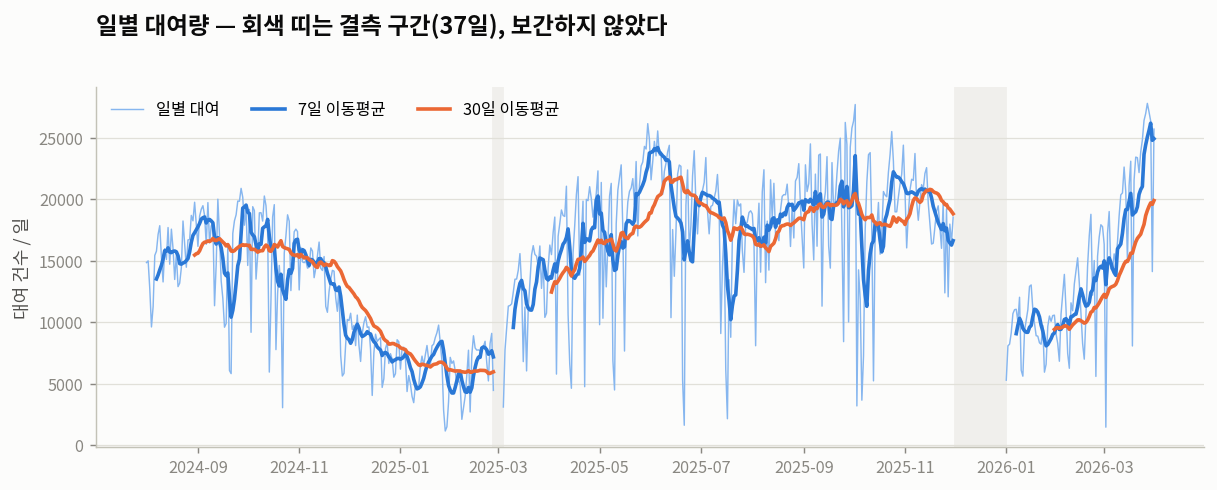

In [8]:
con.execute(f"CREATE VIEW h AS SELECT * FROM read_parquet('{PROC/'station_hourly.parquet'}')")
con.register("m", master)
daily = con.execute("""SELECT h.ts::DATE AS d, sum(h.rentals_real) AS n
    FROM h JOIN m ON h.station_id=m.station_id WHERE m.station_type<>'CONTROL'
    GROUP BY 1 ORDER BY 1""").df()
daily["d"] = pd.to_datetime(daily["d"])
idx = pd.date_range(daily.d.min(), daily.d.max(), freq="D")
s = daily.set_index("d")["n"].reindex(idx)
s = s.mask(s.fillna(0) == 0)   # 재배치 이벤트 때문에 결측일에도 행이 생긴다 → 되돌린다
print(f"전체 {len(idx)}일 중 관측 {s.notna().sum()}일 / 결측 {s.isna().sum()}일")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(s.index, s.values, lw=.8, color=vs.BLUES[3], label="일별 대여")
ax.plot(s.index, s.rolling(7, min_periods=7).mean(), lw=2, color=vs.SERIES[0], label="7일 이동평균")
ax.plot(s.index, s.rolling(30, min_periods=30).mean(), lw=2, color=vs.SERIES[1], label="30일 이동평균")
for a, b in [("2025-02-26","2025-02-28"), ("2025-03-01","2025-03-03"), ("2025-12-01","2025-12-31")]:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b) + pd.Timedelta(days=1), color="#f0efec", zorder=0)
ax.set_title("일별 대여량 — 회색 띠는 결측 구간(37일), 보간하지 않았다")
ax.set_ylabel("대여 건수 / 일"); ax.grid(axis="y"); ax.legend(ncol=3); plt.show()

결측 구간을 **보간하지 않고 선을 끊었다.** 보간하면 없는 데이터를 근거로 말하게 된다.
그리고 겨울에 결측이 몰려 있어서, 이걸 모르면 "겨울에 급감"으로 오독하기 쉽다.

이제 **월별 일평균**으로 정규화해 전년 동월과 비교한다.
총합으로 비교하면 결측일 수 차이가 계절 효과로 둔갑한다.

In [9]:
mm = s.dropna().groupby(s.dropna().index.to_period("M")).agg(["size", "mean"])
mm.columns = ["관측일수", "일평균"]
mm["일평균"] = mm["일평균"].round(0)
yoy = []
for pm in mm.index:
    prev = pm - 12
    if prev in mm.index:
        yoy.append({"월": str(pm), "일평균": int(mm.loc[pm, "일평균"]),
                    "전년동월": int(mm.loc[prev, "일평균"]),
                    "증감%": round((mm.loc[pm, "일평균"] / mm.loc[prev, "일평균"] - 1) * 100, 1)})
display(pd.DataFrame(yoy))
print(f"계절 진폭: 최저 {int(mm['일평균'].min()):,}건/일 ↔ 최고 {int(mm['일평균'].max()):,}건/일 "
      f"= {mm['일평균'].max()/mm['일평균'].min():.1f}배")

,월,일평균,전년동월,증감%
0,2025-08,18411,15543,18.5
1,2025-09,19895,16286,22.2
2,2025-10,18445,15469,19.2
3,2025-11,18812,12910,45.7
4,2026-01,9409,6144,53.1
5,2026-02,12237,6373,92.0
6,2026-03,19774,12210,61.9


계절 진폭: 최저 6,144건/일 ↔ 최고 19,895건/일 = 3.2배


---
## 5단계 · 핵심 인사이트의 근거 수치

리포트의 결론 두 개를 직접 재계산한다.

In [10]:
print("[인사이트 3] 부족은 총량이 아니라 비대칭의 문제다")
print(f"  대여량 ↔ 일평균 순유출 상관: {met.rentals.corr(met.net_out_per_day):.3f}  (사실상 무관)")
print(f"  CPI    ↔ 일평균 순유출 상관: {met.CPI.corr(met.net_out_per_day):.3f}  (이용 유형으로는 예측 못 함)")
cols = ["name", "rentals", "net_out", "net_out_per_day"]
print("\n  대여량 상위 5 — 일평균 순유출이 전부 ±1대 이내다")
display(met.nlargest(5, "rentals")[cols])
print("  순유출 상위 5 — 대여량은 중위권인데 하루 2대 넘게 빠진다")
display(met.nlargest(5, "net_out_per_day")[cols])

[인사이트 3] 부족은 총량이 아니라 비대칭의 문제다
  대여량 ↔ 일평균 순유출 상관: -0.172  (사실상 무관)
  CPI    ↔ 일평균 순유출 상관: -0.060  (이용 유형으로는 예측 못 함)

  대여량 상위 5 — 일평균 순유출이 전부 ±1대 이내다


,name,rentals,net_out,net_out_per_day
8,만년동 한밭수목원(동원),63136.0,591.0,1.033
1306,어은동 한빛아파트(126동 건너편),61878.0,-198.0,-0.346
1309,구성동 카이스트 서쪽 쪽문,59948.0,-208.0,-0.364
1286,궁동 충남대학교 학생회관,56495.0,-135.0,-0.236
370,도룡동 무역전시관입구(미래에너지움 앞),55220.0,15.0,0.026


  순유출 상위 5 — 대여량은 중위권인데 하루 2대 넘게 빠진다


,name,rentals,net_out,net_out_per_day
0,목동 한사랑아파트 109동,11697.0,1580.0,2.762
1,장동 대덕대학교,3505.0,1269.0,2.219
2,하기동 송림마을 5단지(오시오칼국수),3084.0,1027.0,1.795
3,지족동 노은3동 행정복지센터(201),5436.0,1021.0,1.785
4,관저동 원앙네거리(관저 지하차도 방면),4168.0,1016.0,1.776


In [11]:
print("[인사이트 4] 재고가 부족하면 실제로 덜 빌려 간다 (검열된 수요)")
curve = pd.read_csv(PROC / "inventory_response_curve.csv")
display(curve[["decile", "mean_dev", "ratio", "n"]].round(3))
print(f"  최저 분위 {curve.ratio.iloc[0]:.3f} ÷ 최고 분위 {curve.ratio.iloc[-1]:.3f} "
      f"= {curve.ratio.iloc[0]/curve.ratio.iloc[-1]:.3f}")
print("\n  ※ 1차 시도에서는 '같은 시각'의 재고로 묶어 최저 분위가 1.057로 가장 높게 나왔다.")
print("     많이 빌려 갔기 때문에 재고가 낮아진 역인과였다. '직전 시각'으로 바꾸자 기울기가 뒤집혔다.")

[인사이트 4] 재고가 부족하면 실제로 덜 빌려 간다 (검열된 수요)


,decile,mean_dev,ratio,n
0,1,-4.998,0.821,74943
1,2,-2.959,0.820,74894
2,3,-2.106,0.828,74855
3,4,-1.426,0.867,74824
4,5,-0.770,0.902,74801
5,6,-0.067,0.970,74769
6,7,0.823,1.050,74737
7,8,2.027,1.137,74709
8,9,3.830,1.218,74684
9,10,8.408,1.360,74662


  최저 분위 0.821 ÷ 최고 분위 1.360 = 0.604

  ※ 1차 시도에서는 '같은 시각'의 재고로 묶어 최저 분위가 1.057로 가장 높게 나왔다.
     많이 빌려 갔기 때문에 재고가 낮아진 역인과였다. '직전 시각'으로 바꾸자 기울기가 뒤집혔다.


---
## 6단계 · 검증 — 리포트의 숫자를 믿을 수 있는가

리포트에 손으로 옮겨 적은 숫자가 산출물과 어긋나는 것이 가장 흔한 사고다.
그래서 주요 주장을 원천 파일에서 다시 계산해 자동 대조한다.

In [12]:
import subprocess
r = subprocess.run([sys.executable, str(ROOT / "src" / "verify_report.py")],
                   capture_output=True, text=True, cwd=ROOT)
print(r.stdout[-1400:] if r.stdout else r.stderr[-800:])

                            1332        1332.0
OK 전체 대여소                                1425        1425.0
OK 자전거 대수                                6776        6776.0
OK 재배치 총건                               89660       89660.0
OK 물리적 재배치(유효)                          56041       56041.0
OK 하루 평균 물리적 재배치                         98.0       97.9738
OK 대여량↔순유출 상관                          -0.172       -0.1717
OK CPI↔순유출 상관                           -0.06       -0.0604
OK 순유출 1위 일평균                            2.76         2.762
OK 순유출 1위 순유출                            1580        1580.0
OK 재고반응 최저분위 비율                         0.821        0.8212
OK 재고반응 최고분위 비율                          1.36        1.3603
OK 재고반응 최저/최고                           0.604        0.6037
OK B2 MAE                               0.591        0.5907
OK B2 RMSE                               1.16        1.1603
OK 유성구 순유출 합계                           11652       11652.0
OK 출퇴근형 대여소 수                             144        

---
## 정리

| 단계 | 이 단계에서 배운 것 |
|---|---|
| 로딩 | 배포처 안내를 그대로 믿지 않는다. 인코딩·날짜 포맷·파일명이 파일마다 다를 수 있다 |
| 정제 | `isna().sum() == 0` 은 데이터가 깨끗하다는 뜻이 아니다. 의미상 이상치를 따로 정의해야 한다 |
| 재구성 | 없는 컬럼은 만들어 낼 수 있다. 단, 만들어 낸 값은 **보존 법칙과 외부 대칭**으로 검증해야 한다 |
| 분석 | 질문마다 맞는 집계 단위가 다르다. 추세는 일 단위, 부족 진단은 시간 단위 |
| 검증 | 그럴듯한 숫자가 나오면 **"우연이라면 얼마가 나와야 하나"** 를 먼저 계산한다 |

전체 결론·인사이트·한계는 [REPORT.md](REPORT.md),
용어는 [GLOSSARY.md](GLOSSARY.md), 단계별 상세 기록은 [reports/](reports/) 를 본다.